# 안전온도 분석

서울시 지역별 안전 인프라(CCTV, 지구대/파출소, 소방서, 안전비상벨)와 범죄 발생 현황을 종합하여 안전온도를 산출합니다.

---

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

# 한글 폰트 설정
plt.rcParams['axes.unicode_minus'] = False
sns.set_style('whitegrid')

print("="*60)
print("지역별 안전온도 분석 시작")
print("="*60)

지역별 안전온도 분석 시작


# 범죄 발생현황 분석

In [24]:
# 1.1 5대 범죄 발생현황
crime_df = pd.read_csv('../data/regionTemp/safe/5대 범죄 발생현황_20251128124024.csv', encoding='utf-8')
print(f"✓ 5대 범죄 발생현황: {crime_df.shape}")
crime_df.head(10)

✓ 5대 범죄 발생현황: (29, 14)


,자치구별(1),자치구별(2),2024,2024.1,2024.2,2024.3,2024.4,2024.5,2024.6,2024.7,2024.8,2024.9,2024.10,2024.11
0,자치구별(1),자치구별(2),합계,합계,합계,합계,합계,합계,합계,합계,합계,합계,합계,합계
1,자치구별(1),자치구별(2),소계,소계,살인,살인,강도,강도,강간·강제추행,강간·강제추행,절도,절도,폭력,폭력
2,자치구별(1),자치구별(2),발생,검거,발생,검거,발생,검거,발생,검거,발생,검거,발생,검거
3,합계,소계,80819,63275,149,137,87,85,5523,5183,35506,22796,39554,35074
4,합계,종로구,2765,3248,2,3,5,10,209,933,1183,1056,1366,1246
5,합계,중구,2955,2180,5,4,5,5,177,121,1398,816,1370,1234
6,합계,용산구,3322,2475,10,6,4,3,267,235,1082,589,1959,1642
7,합계,성동구,2117,1510,5,6,3,3,114,90,966,544,1029,867
8,합계,광진구,2870,2219,2,2,6,7,235,183,1320,942,1307,1085
9,합계,동대문구,3216,2482,7,6,4,2,125,110,1617,1060,1463,1304


## 구별 범죄 발생 현황

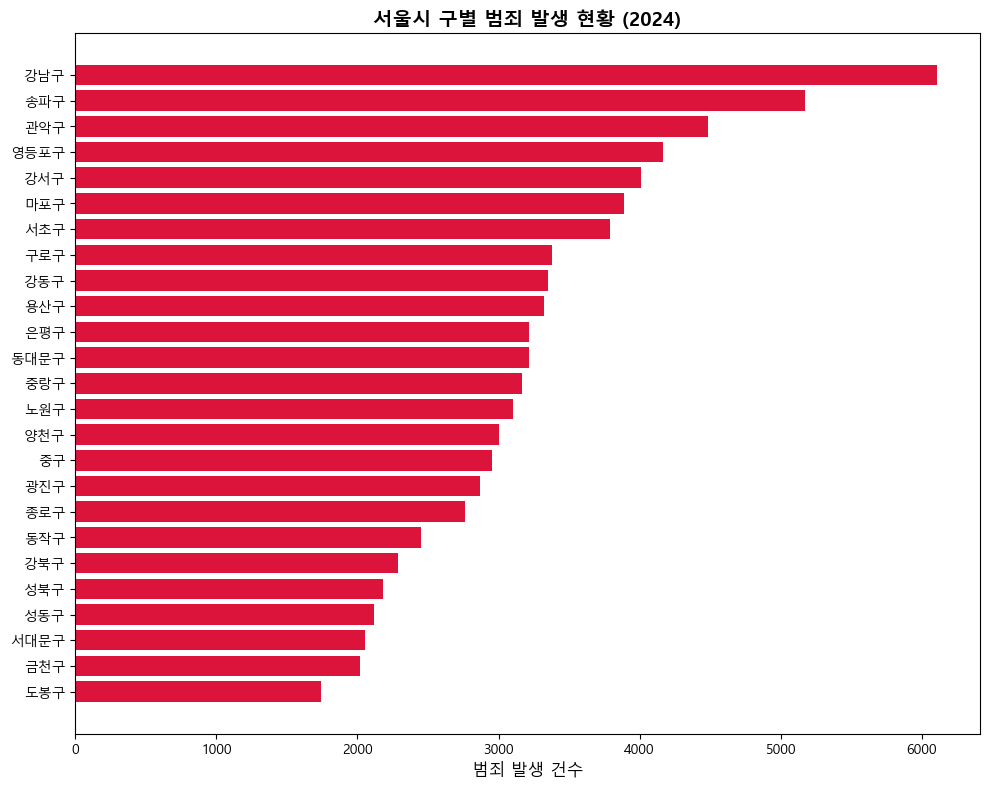


총 25개 지역
평균 범죄 발생: 3233건
최대: 6107건 (강남구)
최소: 1741건 (도봉구)


In [2]:
# 범죄 데이터 구조 확인 및 시각화
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from matplotlib import font_manager, rc

# 한글 폰트 설정 (Windows)
plt.rcParams['font.family'] = 'Malgun Gothic'  # 맑은 고딕
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

# 범죄 데이터 로드
crime_df = pd.read_csv('../data/regionTemp/safe/5대 범죄 발생현황_20251128124024.csv', encoding='utf-8')

# 실제 데이터 추출 (4행부터)
crime_visual = crime_df.iloc[3:].copy()
crime_visual['region'] = crime_df.iloc[3:]['자치구별(2)'].values
crime_visual['crime_count'] = pd.to_numeric(crime_df.iloc[3:]['2024'].values, errors='coerce')
crime_visual = crime_visual[crime_visual['region'] != '소계'].copy()
crime_visual = crime_visual.dropna(subset=['crime_count'])

# 구별 범죄 발생 통계 그래프
plt.figure(figsize=(10, 8))

crime_sorted = crime_visual.sort_values('crime_count', ascending=False)
plt.barh(crime_sorted['region'], crime_sorted['crime_count'], color='crimson')
plt.xlabel('범죄 발생 건수', fontsize=12)
plt.title('서울시 구별 범죄 발생 현황 (2024)', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

# 통계 요약
print(f"\n총 {len(crime_visual)}개 지역")
print(f"평균 범죄 발생: {crime_visual['crime_count'].mean():.0f}건")
print(f"최대: {crime_visual['crime_count'].max():.0f}건 ({crime_visual.loc[crime_visual['crime_count'].idxmax(), 'region']})")
print(f"최소: {crime_visual['crime_count'].min():.0f}건 ({crime_visual.loc[crime_visual['crime_count'].idxmin(), 'region']})")


## 구별 범죄 발생 유형 분석 (발생 및 검거 비율)

분석 대상 지역: 21개
  region  살인_발생  살인_검거  강도_발생  강도_검거
1    종로구      2      3    5.0   10.0
2     중구      5      4    5.0    5.0
3    용산구     10      6    4.0    3.0
4    성동구      5      6    3.0    3.0
5    광진구      2      2    6.0    7.0


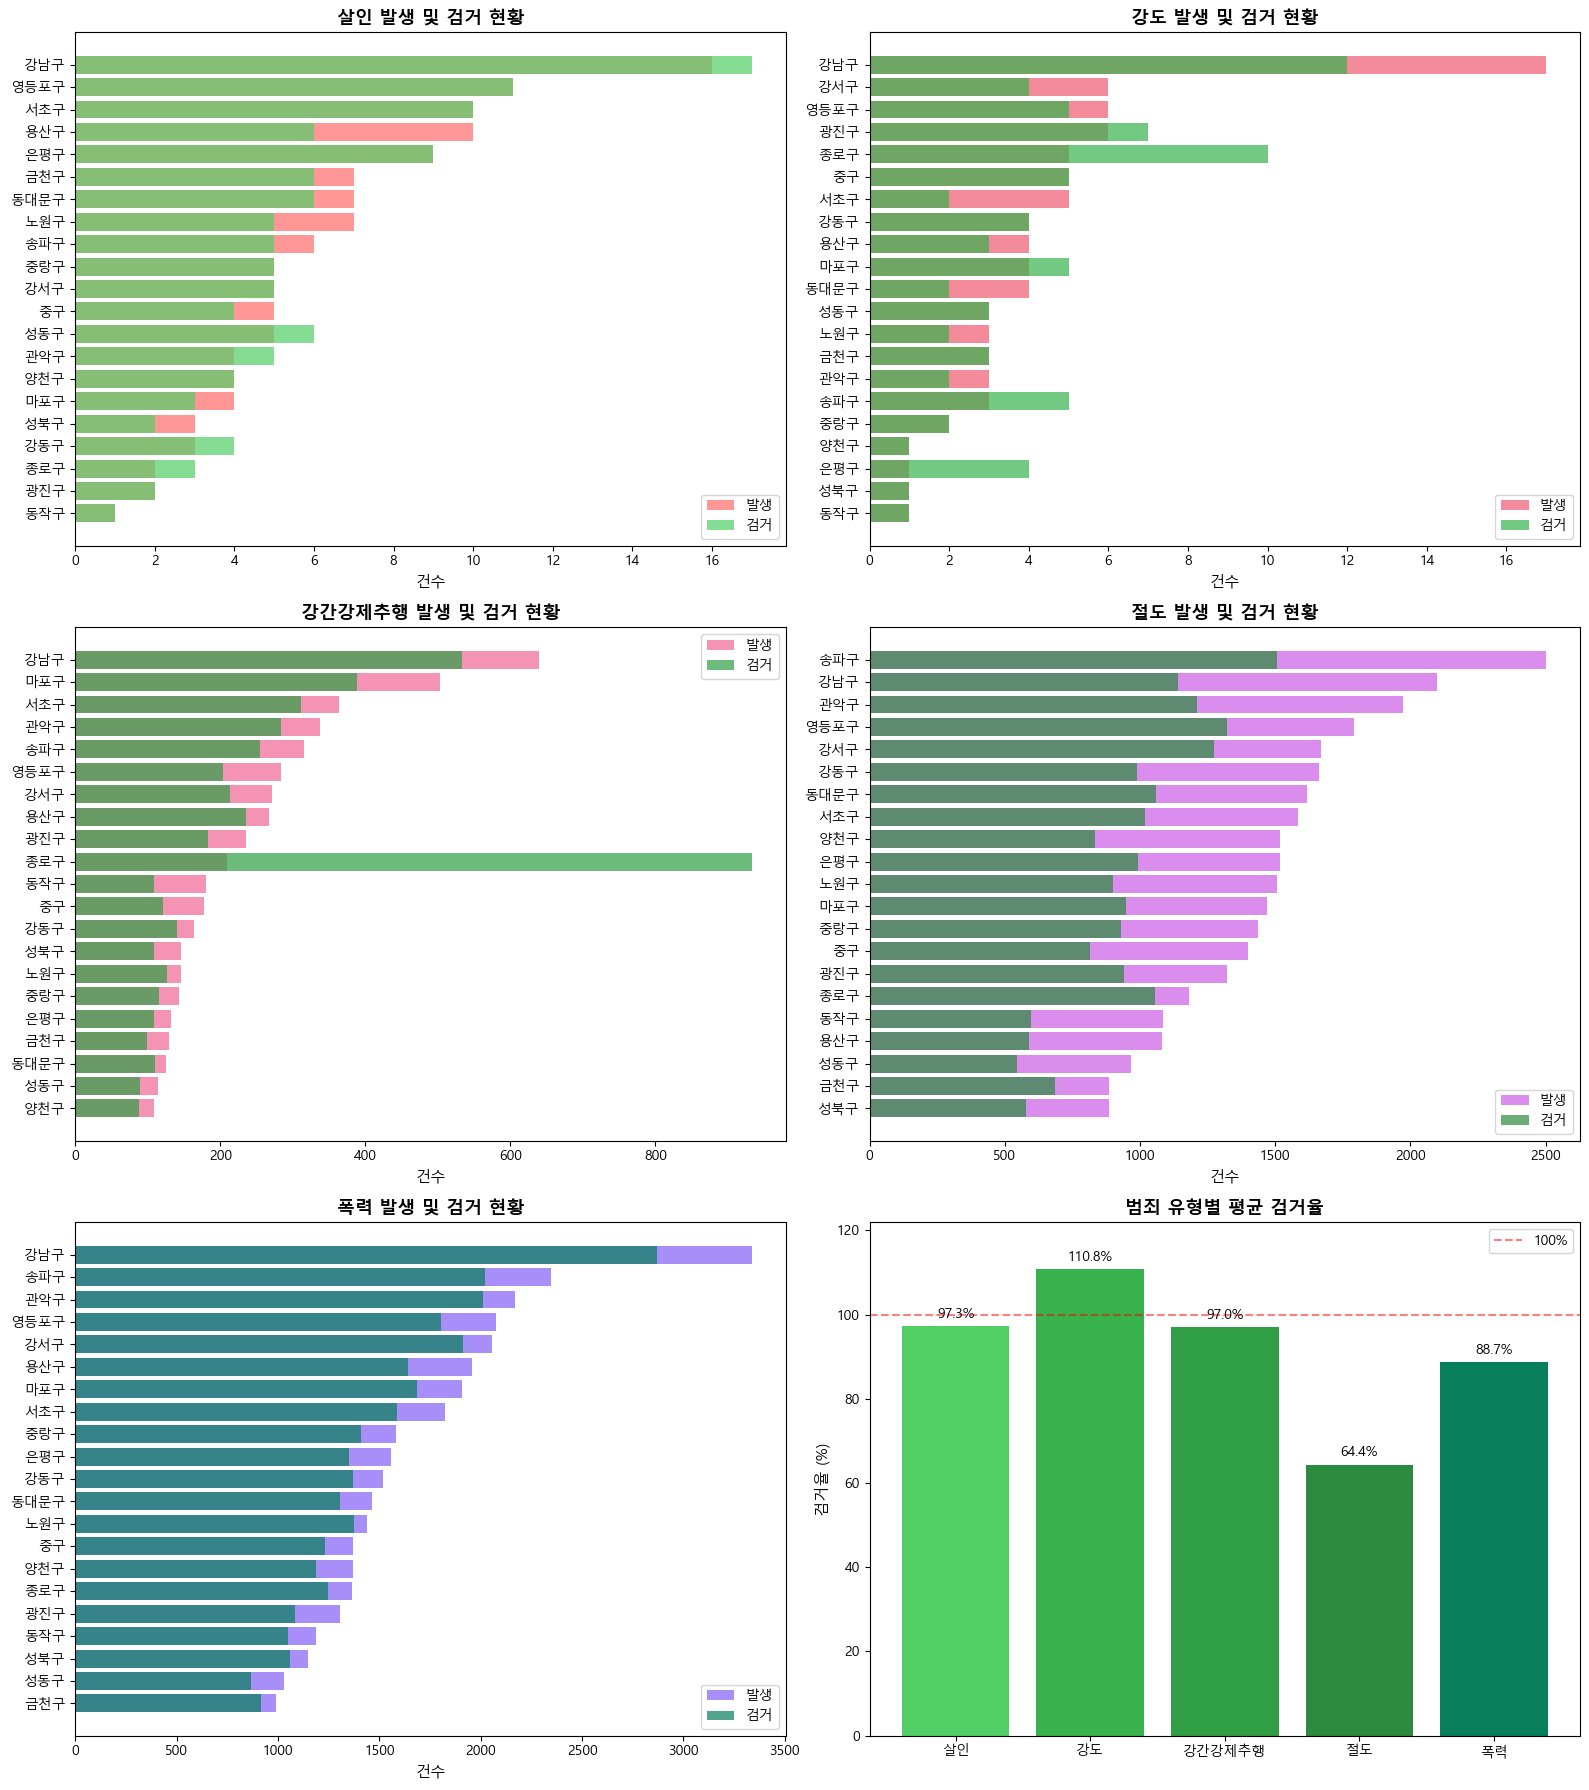


=== 범죄 유형별 통계 ===

살인:
  총 발생: 126건
  총 검거: 119건
  검거율: 94.4%

강도:
  총 발생: 87건
  총 검거: 83건
  검거율: 95.4%

강간강제추행:
  총 발생: 4991건
  총 검거: 4758건
  검거율: 95.3%

절도:
  총 발생: 31150건
  총 검거: 19935건
  검거율: 64.0%

폭력:
  총 발생: 35003건
  총 검거: 30991건
  검거율: 88.5%


In [4]:
# 범죄 유형별 발생 및 검거 비율 분석
import matplotlib.pyplot as plt
import pandas as pd

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 범죄 데이터 로드
crime_df = pd.read_csv('../data/regionTemp/safe/5대 범죄 발생현황_20251128124024.csv', encoding='utf-8')

# 실제 데이터 추출 (4행부터, index=3부터)
crime_detail = crime_df.iloc[3:].reset_index(drop=True).copy()

# 지역명 추출
crime_detail['region'] = crime_detail['자치구별(2)']
crime_detail = crime_detail[crime_detail['region'] != '소계'].copy()

# 각 범죄 유형별 발생/검거 데이터 추출
crime_detail['살인_발생'] = pd.to_numeric(crime_detail['2024.2'], errors='coerce')
crime_detail['살인_검거'] = pd.to_numeric(crime_detail['2024.3'], errors='coerce')
crime_detail['강도_발생'] = pd.to_numeric(crime_detail['2024.4'], errors='coerce')
crime_detail['강도_검거'] = pd.to_numeric(crime_detail['2024.5'], errors='coerce')
crime_detail['강간강제추행_발생'] = pd.to_numeric(crime_detail['2024.6'], errors='coerce')
crime_detail['강간강제추행_검거'] = pd.to_numeric(crime_detail['2024.7'], errors='coerce')
crime_detail['절도_발생'] = pd.to_numeric(crime_detail['2024.8'], errors='coerce')
crime_detail['절도_검거'] = pd.to_numeric(crime_detail['2024.9'], errors='coerce')
crime_detail['폭력_발생'] = pd.to_numeric(crime_detail['2024.10'], errors='coerce')
crime_detail['폭력_검거'] = pd.to_numeric(crime_detail['2024.11'], errors='coerce')

crime_detail = crime_detail.dropna()

# 검거율 계산
crime_detail['살인_검거율'] = (crime_detail['살인_검거'] / crime_detail['살인_발생'] * 100).replace([float('inf'), -float('inf')], 0).fillna(0)
crime_detail['강도_검거율'] = (crime_detail['강도_검거'] / crime_detail['강도_발생'] * 100).replace([float('inf'), -float('inf')], 0).fillna(0)
crime_detail['강간강제추행_검거율'] = (crime_detail['강간강제추행_검거'] / crime_detail['강간강제추행_발생'] * 100).replace([float('inf'), -float('inf')], 0).fillna(0)
crime_detail['절도_검거율'] = (crime_detail['절도_검거'] / crime_detail['절도_발생'] * 100).replace([float('inf'), -float('inf')], 0).fillna(0)
crime_detail['폭력_검거율'] = (crime_detail['폭력_검거'] / crime_detail['폭력_발생'] * 100).replace([float('inf'), -float('inf')], 0).fillna(0)

print(f"분석 대상 지역: {len(crime_detail)}개")
print(crime_detail[['region', '살인_발생', '살인_검거', '강도_발생', '강도_검거']].head())

# 시각화
fig, axes = plt.subplots(3, 2, figsize=(16, 18))

crime_types = ['살인', '강도', '강간강제추행', '절도', '폭력']
colors_occur = ['#ff6b6b', '#ee5a6f', '#f06595', '#cc5de8', '#845ef7']
colors_arrest = ['#51cf66', '#37b24d', '#2f9e44', '#2b8a3e', '#087f5b']

for idx, crime_type in enumerate(crime_types):
    row = idx // 2
    col = idx % 2
    
    # 발생 건수로 정렬
    crime_sorted = crime_detail.sort_values(f'{crime_type}_발생', ascending=False)
    
    axes[row, col].barh(crime_sorted['region'], crime_sorted[f'{crime_type}_발생'], 
                        color=colors_occur[idx], alpha=0.7, label='발생')
    axes[row, col].barh(crime_sorted['region'], crime_sorted[f'{crime_type}_검거'], 
                        color=colors_arrest[idx], alpha=0.7, label='검거')
    
    axes[row, col].set_xlabel('건수', fontsize=11)
    axes[row, col].set_title(f'{crime_type} 발생 및 검거 현황', fontsize=13, fontweight='bold')
    axes[row, col].legend()
    axes[row, col].invert_yaxis()

# 검거율 비교
axes[2, 1].clear()
avg_arrest_rates = {
    '살인': crime_detail['살인_검거율'].mean(),
    '강도': crime_detail['강도_검거율'].mean(),
    '강간강제추행': crime_detail['강간강제추행_검거율'].mean(),
    '절도': crime_detail['절도_검거율'].mean(),
    '폭력': crime_detail['폭력_검거율'].mean()
}

axes[2, 1].bar(avg_arrest_rates.keys(), avg_arrest_rates.values(), 
               color=['#51cf66', '#37b24d', '#2f9e44', '#2b8a3e', '#087f5b'])
axes[2, 1].set_ylabel('검거율 (%)', fontsize=11)
axes[2, 1].set_title('범죄 유형별 평균 검거율', fontsize=13, fontweight='bold')
axes[2, 1].axhline(y=100, color='red', linestyle='--', alpha=0.5, label='100%')
axes[2, 1].legend()
axes[2, 1].set_ylim(0, max(avg_arrest_rates.values()) * 1.1)

# 값 표시
for i, (crime, rate) in enumerate(avg_arrest_rates.items()):
    axes[2, 1].text(i, rate + 2, f'{rate:.1f}%', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

# 통계 요약
print("\n=== 범죄 유형별 통계 ===")
for crime_type in crime_types:
    total_occur = crime_detail[f'{crime_type}_발생'].sum()
    total_arrest = crime_detail[f'{crime_type}_검거'].sum()
    arrest_rate = (total_arrest / total_occur * 100) if total_occur > 0 else 0
    print(f"\n{crime_type}:")
    print(f"  총 발생: {total_occur:.0f}건")
    print(f"  총 검거: {total_arrest:.0f}건")
    print(f"  검거율: {arrest_rate:.1f}%")

# CCTV 현황 분석

In [10]:
# 1.2 CCTV 정보
cctv_df = pd.read_excel('../data/regionTemp/safe/CCTV정보.xlsx')
print(f"✓ CCTV 정보: {cctv_df.shape}")
cctv_df.head()

✓ CCTV 정보: (57699, 14)


,번호,관리기관명,소재지도로명주소,소재지지번주소,설치목적구분,카메라대수,카메라화소수,촬영방면정보,보관일수,설치연월,관리기관전화번호,WGS84위도,WGS84경도,데이터기준일자
0,1,서울특별시 성동구청,서울특별시 마조로 11,서울특별시 행당동 19-98,교통단속,3,200,360도전방면,30,2013-11,02-2286-5878,37.558960,127.040794,2022-06-24
1,2,서울특별시 성동구청,서울특별시 고산자로 330 (마장동),서울특별시 마장동 520-10,교통단속,2,200,360도전방면,30,2013-11,02-2286-5878,37.569137,127.037521,2022-06-24
2,3,서울특별시 성동구청,서울특별시 마장로35길 76,서울특별시 마장동 818,교통단속,3,200,360도전방면,30,2013-11,02-2286-5878,37.570602,127.042519,2022-06-24
3,4,서울특별시 성동구청,서울특별시 마장로 325 (마장동),서울특별시 마장동 767-41,교통단속,3,200,360도전방면,30,2017-11,02-2286-5878,37.567585,127.044815,2022-06-24
4,5,서울특별시 성동구청,서울특별시 마장로 322 (마장동),서울특별시 마장동 781-1,교통단속,2,200,360도전방면,30,2017-11,02-2286-5878,37.566624,127.043945,2022-06-24


## CCTV 설치 목적

In [11]:
# CCTV 설치목적구분 확인
print("=== CCTV 설치목적구분 ===")
print(cctv_df['설치목적구분'].value_counts())

print("\n=== 설치목적구분 종류 ===")
print(cctv_df['설치목적구분'].unique())

print(f"\n총 {cctv_df['설치목적구분'].nunique()}개 유형")

=== CCTV 설치목적구분 ===
설치목적구분
생활방범      37244
다목적        5532
교통단속       5105
어린이보호      3739
시설물관리      1803
기타         1628
재난재해       1240
쓰레기단속      1234
차량방범        153
교통정보수집       21
Name: count, dtype: int64

=== 설치목적구분 종류 ===
['교통단속' '쓰레기단속' '생활방범' '차량방범' '시설물관리' '다목적' '재난재해' '기타' '어린이보호' '교통정보수집']

총 10개 유형


In [16]:
# 구별 
# "서울특별시", "서울시", 또는 아무것도 없는 경우 모두 처리
cctv_df['region'] = cctv_df['관리기관명'].str.extract(r'(?:서울특별시|서울시)?\s*(\S+구)')

# 확인
print(f"총 구 개수: {cctv_df['region'].nunique()}개")
print("\n구별 개수:")
print(cctv_df['region'].value_counts().sort_index())

# 다시 집계
cctv_pivot = cctv_df.groupby(['region', '설치목적구분']).size().unstack(fill_value=0)

# 안전 관련 CCTV만 따로 집계
safety_purposes = ['생활방범', '차량방범', '어린이보호']
cctv_pivot['안전CCTV합계'] = cctv_pivot[safety_purposes].sum(axis=1)

print("\n=== 구별 안전 관련 CCTV 합계 ===")
print(cctv_pivot[['생활방범', '차량방범', '어린이보호', '안전CCTV합계']].sort_values('안전CCTV합계', ascending=False))

# 25개 구 모두 있는지 확인
seoul_districts = [
    '강남구', '강동구', '강북구', '강서구', '관악구', '광진구', '구로구', '금천구',
    '노원구', '도봉구', '동대문구', '동작구', '마포구', '서대문구', '서초구',
    '성동구', '성북구', '송파구', '양천구', '영등포구', '용산구', '은평구',
    '종로구', '중구', '중랑구'
]

extracted = set(cctv_df['region'].dropna().unique())
missing = set(seoul_districts) - extracted

if missing:
    print(f"\n아직 누락된 구: {missing}")
else:
    print("\n✓ 25개 구 모두 추출 완료!")


총 구 개수: 25개

구별 개수:
region
강남구     2578
강동구     1461
강북구     4360
강서구     1964
관악구     2040
광진구     1304
구로구     2132
금천구      935
노원구     3111
도봉구     2807
동대문구    1324
동작구      890
마포구     1497
서대문구    1292
서초구     6324
성동구     1314
성북구     2366
송파구     1829
양천구     4795
영등포구    5300
용산구     1930
은평구     1773
종로구     1224
중구      1156
중랑구     1993
Name: count, dtype: int64

=== 구별 안전 관련 CCTV 합계 ===
설치목적구분  생활방범  차량방범  어린이보호  안전CCTV합계
region                             
양천구     3432     0    910      4342
강북구     3844     0    356      4200
서초구     3903     0    200      4103
도봉구     2429     0    196      2625
강남구     2010     0      0      2010
노원구     1625     0    302      1927
중랑구     1679     0    122      1801
강서구     1674     0    126      1800
구로구     1495     0    229      1724
용산구     1493     0    118      1611
송파구     1304     0    192      1496
성북구     1331     0    164      1495
은평구     1389     0      0      1389
강동구     1216     0    143      1359
마포구     1349     0  

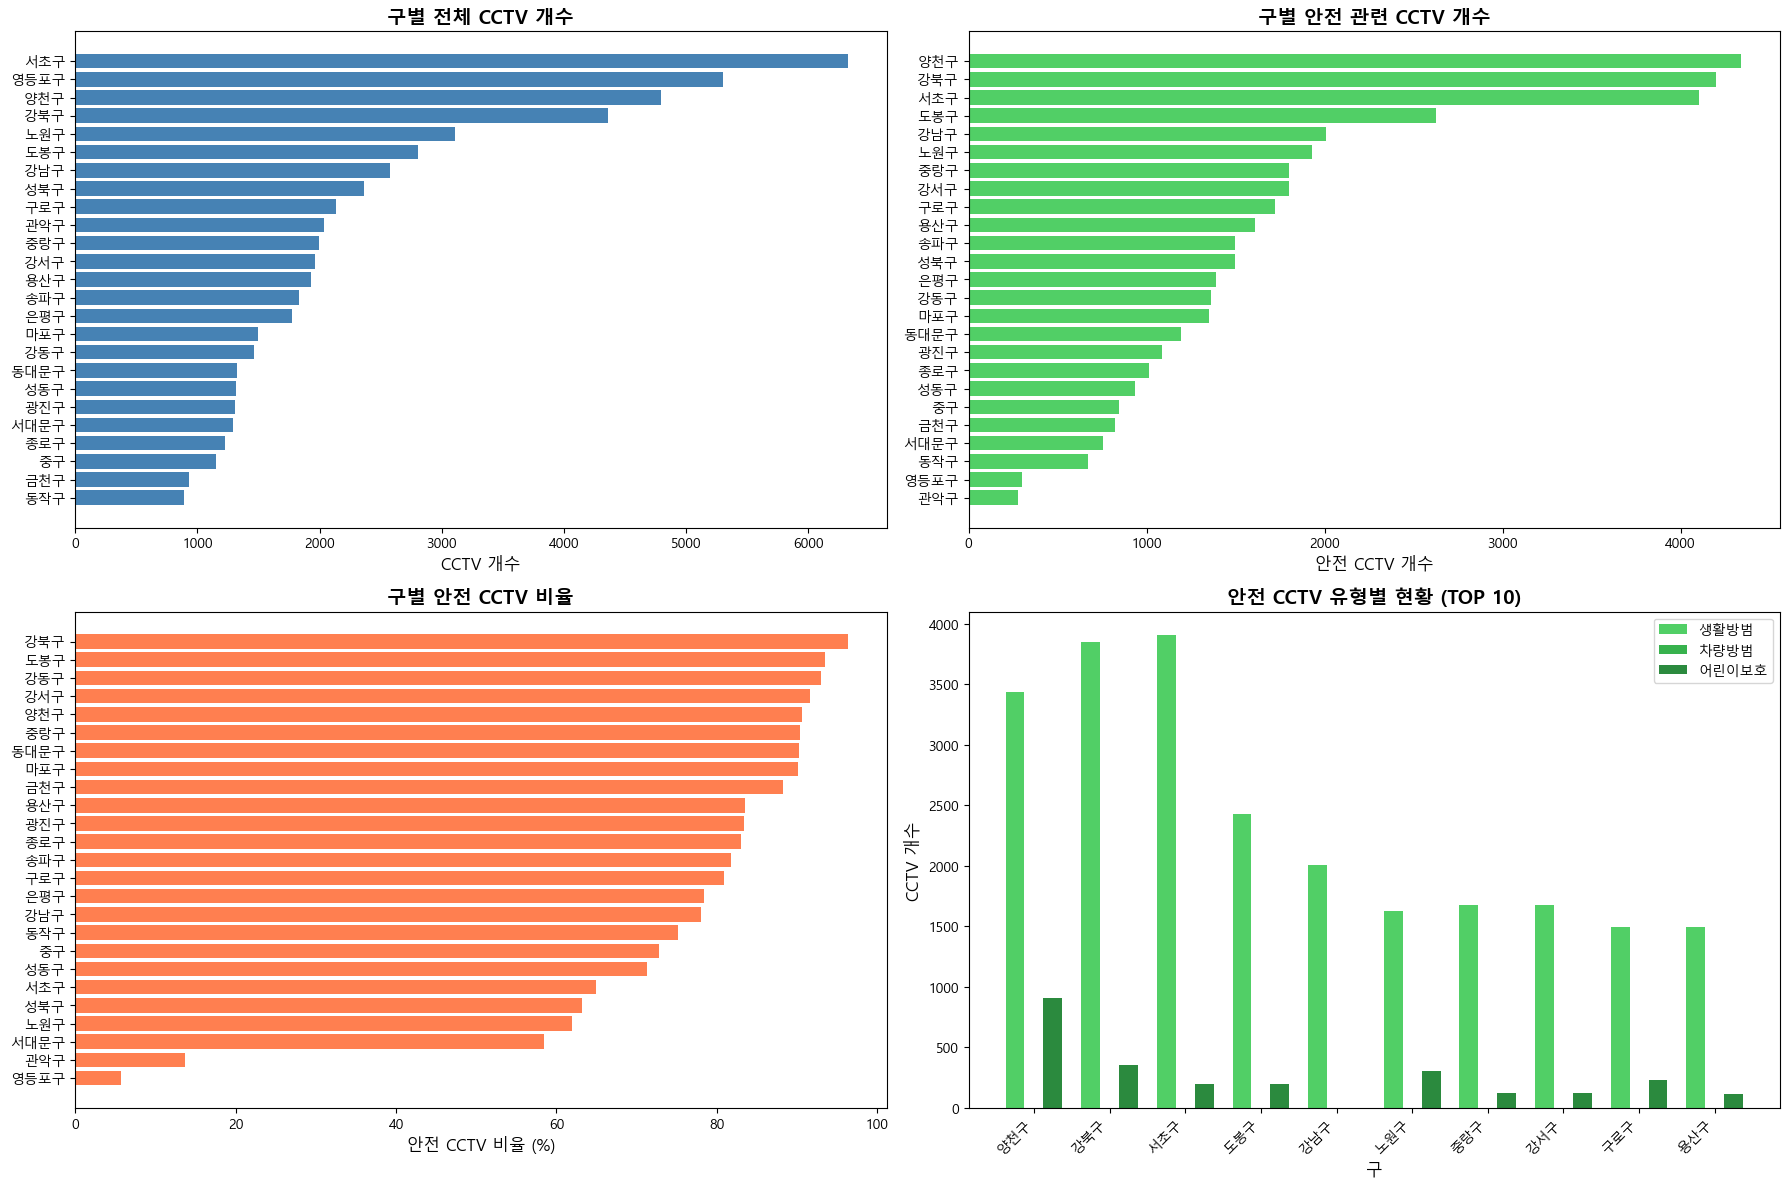


=== CCTV 통계 요약 ===
전체 CCTV: 57,699대
안전 CCTV: 41,136대 (71.3%)

평균 (구당):
  전체 CCTV: 2308대
  안전 CCTV: 1645대

최대:
  전체 CCTV: 6324대 (서초구)
  안전 CCTV: 4342대 (양천구)

최소:
  전체 CCTV: 890대 (동작구)
  안전 CCTV: 279대 (관악구)


In [17]:
import matplotlib.pyplot as plt
import numpy as np

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 1. 전체 CCTV 개수 (단순 막대그래프)
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# 1-1. 전체 CCTV 개수
total_cctv = cctv_df.groupby('region').size().sort_values(ascending=False)
axes[0, 0].barh(total_cctv.index, total_cctv.values, color='steelblue')
axes[0, 0].set_xlabel('CCTV 개수', fontsize=12)
axes[0, 0].set_title('구별 전체 CCTV 개수', fontsize=14, fontweight='bold')
axes[0, 0].invert_yaxis()

# 1-2. 안전 CCTV 개수
safety_cctv = cctv_pivot['안전CCTV합계'].sort_values(ascending=False)
axes[0, 1].barh(safety_cctv.index, safety_cctv.values, color='#51cf66')
axes[0, 1].set_xlabel('안전 CCTV 개수', fontsize=12)
axes[0, 1].set_title('구별 안전 관련 CCTV 개수', fontsize=14, fontweight='bold')
axes[0, 1].invert_yaxis()

# 1-3. 안전 CCTV 비율
cctv_total_by_region = cctv_df.groupby('region').size()
safety_ratio = (cctv_pivot['안전CCTV합계'] / cctv_total_by_region * 100).sort_values(ascending=False)
axes[1, 0].barh(safety_ratio.index, safety_ratio.values, color='coral')
axes[1, 0].set_xlabel('안전 CCTV 비율 (%)', fontsize=12)
axes[1, 0].set_title('구별 안전 CCTV 비율', fontsize=14, fontweight='bold')
axes[1, 0].invert_yaxis()

# 1-4. 안전 CCTV 유형별 (상위 10개 구)
top10_regions = cctv_pivot['안전CCTV합계'].nlargest(10).index
top10_data = cctv_pivot.loc[top10_regions, ['생활방범', '차량방범', '어린이보호']]

x = np.arange(len(top10_regions))
width = 0.25

axes[1, 1].bar(x - width, top10_data['생활방범'], width, label='생활방범', color='#51cf66')
axes[1, 1].bar(x, top10_data['차량방범'], width, label='차량방범', color='#37b24d')
axes[1, 1].bar(x + width, top10_data['어린이보호'], width, label='어린이보호', color='#2b8a3e')

axes[1, 1].set_xlabel('구', fontsize=12)
axes[1, 1].set_ylabel('CCTV 개수', fontsize=12)
axes[1, 1].set_title('안전 CCTV 유형별 현황 (TOP 10)', fontsize=14, fontweight='bold')
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(top10_regions, rotation=45, ha='right')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

# 통계 요약
print("\n=== CCTV 통계 요약 ===")
print(f"전체 CCTV: {len(cctv_df):,}대")
print(f"안전 CCTV: {cctv_pivot['안전CCTV합계'].sum():,.0f}대 ({cctv_pivot['안전CCTV합계'].sum()/len(cctv_df)*100:.1f}%)")
print(f"\n평균 (구당):")
print(f"  전체 CCTV: {cctv_total_by_region.mean():.0f}대")
print(f"  안전 CCTV: {cctv_pivot['안전CCTV합계'].mean():.0f}대")
print(f"\n최대:")
print(f"  전체 CCTV: {cctv_total_by_region.max():.0f}대 ({cctv_total_by_region.idxmax()})")
print(f"  안전 CCTV: {cctv_pivot['안전CCTV합계'].max():.0f}대 ({cctv_pivot['안전CCTV합계'].idxmax()})")
print(f"\n최소:")
print(f"  전체 CCTV: {cctv_total_by_region.min():.0f}대 ({cctv_total_by_region.idxmin()})")
print(f"  안전 CCTV: {cctv_pivot['안전CCTV합계'].min():.0f}대 ({cctv_pivot['안전CCTV합계'].idxmin()})")


# 지구대/파출소 정보

In [19]:
# 1.3 지구대/파출소 정보
try:
    police_df = pd.read_csv('../data/regionTemp/safe/경찰청_전국 지구대 파출소 주소 현황_20241231.csv', encoding='utf-8')
except UnicodeDecodeError:
    try:
        police_df = pd.read_csv('../data/regionTemp/safe/경찰청_전국 지구대 파출소 주소 현황_20241231.csv', encoding='cp949')
    except UnicodeDecodeError:
        police_df = pd.read_csv('../data/regionTemp/safe/경찰청_전국 지구대 파출소 주소 현황_20241231.csv', encoding='euc-kr')
        
print(f"✓ 지구대/파출소 정보: {police_df.shape}")
police_df.head()

✓ 지구대/파출소 정보: (2045, 7)


,연번,시도청,경찰서,관서명,구분,전화번호,주소
0,1,서울청,서울중부,을지,지구대,02-2279-1908,서울특별시 중구 퇴계로49길 13
1,2,서울청,서울중부,광희,지구대,02-2233-1444,서울특별시 중구 퇴계로 375-1
2,3,서울청,서울중부,약수,지구대,02-2234-8112,서울특별시 중구 동호로 5길 15
3,4,서울청,서울중부,신당,파출소,02-2252-0435,"서울특별시 중구 다산로 248 (신당동, 신당파출소)"
4,5,서울청,서울중부,장충,파출소,02-2274-9003,서울특별시 중구 동호로 261


총 구 개수: 25개

구별 지구대/파출소 수:
   region  police_count
22    종로구            20
23     중구            15
0     강남구            14
3     강서구            11
10   동대문구            11
14    서초구            11
17    송파구            11
19   영등포구            10
5     광진구            10
16    성북구            10
2     강북구             9
21    은평구             9
4     관악구             9
1     강동구             9
15    성동구             9
6     구로구             8
8     노원구             8
24    중랑구             8
13   서대문구             8
12    마포구             8
9     도봉구             8
18    양천구             8
11    동작구             7
20    용산구             7
7     금천구             5


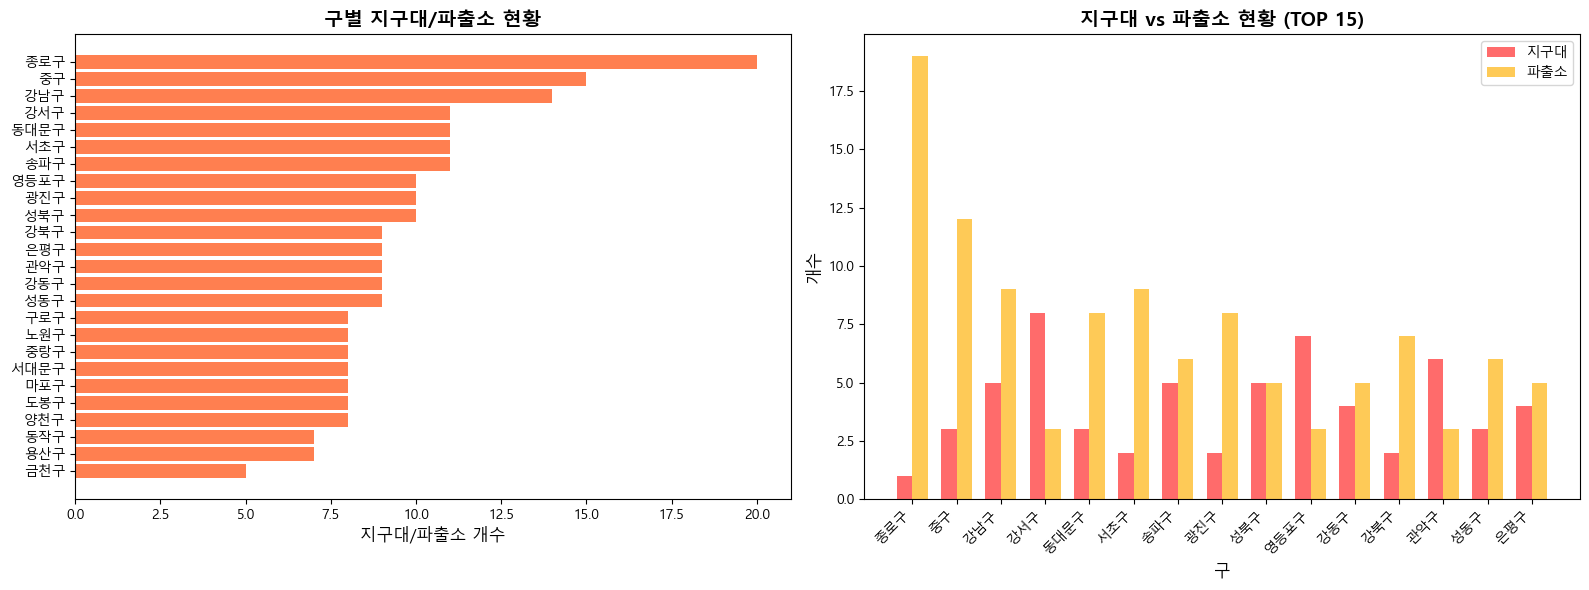


=== 지구대/파출소 통계 ===
총 개수: 243개
평균 (구당): 9.7개
최대: 20개 (종로구)
최소: 5개 (금천구)

구분별:
구분
파출소    144
지구대     99
Name: count, dtype: int64


In [20]:
# 지구대/파출소 구별 집계
import matplotlib.pyplot as plt

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 서울시만 필터링
seoul_police = police_df[police_df['시도청'] == '서울청'].copy()

# 주소에서 구 이름 추출
seoul_police['region'] = seoul_police['주소'].str.extract(r'(?:서울특별시|서울시)?\s*(\S+구)')

# 구별 집계
police_by_region = seoul_police.groupby('region').size().reset_index(name='police_count')

print(f"총 구 개수: {len(police_by_region)}개")
print("\n구별 지구대/파출소 수:")
print(police_by_region.sort_values('police_count', ascending=False))

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 전체 구
police_sorted = police_by_region.sort_values('police_count', ascending=False)
axes[0].barh(police_sorted['region'], police_sorted['police_count'], color='coral')
axes[0].set_xlabel('지구대/파출소 개수', fontsize=12)
axes[0].set_title('구별 지구대/파출소 현황', fontsize=14, fontweight='bold')
axes[0].invert_yaxis()

# 구분별 (지구대 vs 파출소)
seoul_police['구분_count'] = 1
police_type = seoul_police.groupby(['region', '구분']).size().unstack(fill_value=0)

# 상위 15개 구
top15 = police_by_region.nlargest(15, 'police_count')['region']
police_type_top15 = police_type.loc[top15]

x = range(len(police_type_top15))
width = 0.35

if '지구대' in police_type_top15.columns:
    axes[1].bar([i - width/2 for i in x], police_type_top15['지구대'], width, label='지구대', color='#ff6b6b')
if '파출소' in police_type_top15.columns:
    axes[1].bar([i + width/2 for i in x], police_type_top15['파출소'], width, label='파출소', color='#feca57')

axes[1].set_xlabel('구', fontsize=12)
axes[1].set_ylabel('개수', fontsize=12)
axes[1].set_title('지구대 vs 파출소 현황 (TOP 15)', fontsize=14, fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(police_type_top15.index, rotation=45, ha='right')
axes[1].legend()

plt.tight_layout()
plt.show()

# 통계 요약
print("\n=== 지구대/파출소 통계 ===")
print(f"총 개수: {len(seoul_police)}개")
print(f"평균 (구당): {police_by_region['police_count'].mean():.1f}개")
print(f"최대: {police_by_region['police_count'].max()}개 ({police_by_region.loc[police_by_region['police_count'].idxmax(), 'region']})")
print(f"최소: {police_by_region['police_count'].min()}개 ({police_by_region.loc[police_by_region['police_count'].idxmin(), 'region']})")

if '구분' in seoul_police.columns:
    print(f"\n구분별:")
    print(seoul_police['구분'].value_counts())


# 소방서 정보

In [22]:
# 1.4 소방서 정보
try:
    fire_df = pd.read_csv('../data/regionTemp/safe/소방청_시도 소방서 현황_20250701.csv', encoding='utf-8')
except UnicodeDecodeError:
    try:
        fire_df = pd.read_csv('../data/regionTemp/safe/소방청_시도 소방서 현황_20250701.csv', encoding='cp949')
    except UnicodeDecodeError:
        fire_df = pd.read_csv('../data/regionTemp/safe/소방청_시도 소방서 현황_20250701.csv', encoding='euc-kr')
        
print(f"✓ 소방서 정보: {fire_df.shape}")
fire_df.head()

✓ 소방서 정보: (242, 6)


,순번,소방본부,소방서,주소,전화번호,팩스번호
0,1,서울특별시,강남소방서,서울특별시 강남구 테헤란로 629 (삼성동),02-6981-7408,02-2187-8220
1,2,서울특별시,강동소방서,서울특별시 강동구 성내로 39 (성내동),02-6981-7673,02-6981-7717
2,3,서울특별시,강북소방서,서울특별시 강북구 한천로 911 (번동),02-6946-0119,02-6946-0183
3,4,서울특별시,강서소방서,서울특별시 강서구 양천로 550 (등촌동),02-6981-5000,02-2187-8243
4,5,서울특별시,관악소방서,서울특별시 관악구 관악로 97 (봉천동),02-6981-8200,02-2187-8300


총 구 개수: 25개

구별 소방서 수:
   region  fire_count
0     강남구           1
1     강동구           1
2     강북구           1
3     강서구           1
4     관악구           1
5     광진구           1
6     구로구           1
7     금천구           1
8     노원구           1
9     도봉구           1
10   동대문구           1
11    동작구           1
12    마포구           1
13   서대문구           1
14    서초구           1
15    성동구           1
16    성북구           1
17    송파구           1
18    양천구           1
19   영등포구           1
20    용산구           1
21    은평구           1
22    종로구           1
23     중구           1
24    중랑구           1


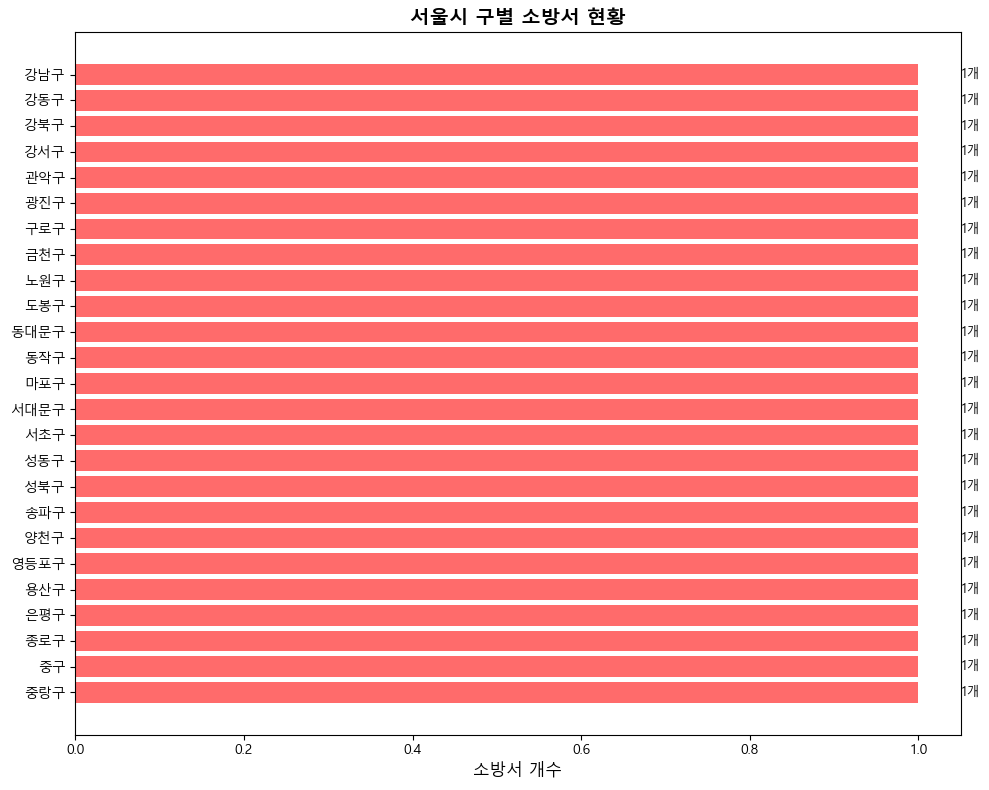


=== 소방서 통계 ===
총 개수: 25개
평균 (구당): 1.0개
최대: 1개 (강남구)
최소: 1개 (강남구)

서울시 소방서 목록:
소방서
강남소방서     1
강동소방서     1
강북소방서     1
강서소방서     1
관악소방서     1
광진소방서     1
구로소방서     1
금천소방서     1
노원소방서     1
도봉소방서     1
동대문소방서    1
동작소방서     1
마포소방서     1
서대문소방서    1
서초소방서     1
성동소방서     1
성북소방서     1
송파소방서     1
양천소방서     1
영등포소방서    1
용산소방서     1
은평소방서     1
종로소방서     1
중랑소방서     1
중부소방서     1
Name: count, dtype: int64


In [23]:
# 소방서 구별 집계
import matplotlib.pyplot as plt

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 서울시만 필터링
seoul_fire = fire_df[fire_df['소방본부'] == '서울특별시'].copy()

# 주소에서 구 이름 추출
seoul_fire['region'] = seoul_fire['주소'].str.extract(r'(?:서울특별시|서울시)?\s*(\S+구)')

# 구별 집계
fire_by_region = seoul_fire.groupby('region').size().reset_index(name='fire_count')

print(f"총 구 개수: {len(fire_by_region)}개")
print("\n구별 소방서 수:")
print(fire_by_region.sort_values('fire_count', ascending=False))

# 시각화
plt.figure(figsize=(10, 8))

fire_sorted = fire_by_region.sort_values('fire_count', ascending=False)
plt.barh(fire_sorted['region'], fire_sorted['fire_count'], color='#ff6b6b')
plt.xlabel('소방서 개수', fontsize=12)
plt.title('서울시 구별 소방서 현황', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()

# 값 표시
for idx, row in fire_sorted.iterrows():
    plt.text(row['fire_count'] + 0.05, row['region'], f"{int(row['fire_count'])}개", 
             va='center', fontsize=9)

plt.tight_layout()
plt.show()

# 통계 요약
print("\n=== 소방서 통계 ===")
print(f"총 개수: {len(seoul_fire)}개")
print(f"평균 (구당): {fire_by_region['fire_count'].mean():.1f}개")
print(f"최대: {fire_by_region['fire_count'].max()}개 ({fire_by_region.loc[fire_by_region['fire_count'].idxmax(), 'region']})")
print(f"최소: {fire_by_region['fire_count'].min()}개 ({fire_by_region.loc[fire_by_region['fire_count'].idxmin(), 'region']})")

# 소방서명 확인
print("\n서울시 소방서 목록:")
print(seoul_fire['소방서'].value_counts())


# 안전 비상벨 정보

In [24]:
# 1.5 안전비상벨 정보
bell_df = pd.read_excel('../data/regionTemp/safe/안전비상벨위치정보(2025.07.31.기준).xlsx')
print(f"✓ 안전비상벨 정보: {bell_df.shape}")
bell_df.head()

✓ 안전비상벨 정보: (49, 16)


,안전비상벨관리번호,설치목적,설치장소유형,설치위치,소재지지번주소,연계방식,경찰연계유무,경비업체연계유무,관리사무소연계유무,부가기능,안전비상벨설치년도,최종점검,최종점검결과구분,관리기관명,관리기관전화번호,데이터기준일자
0,82000001,1,99,화곡터널 내 보행로,서울특별시 강서구 화곡동 산143-2~화곡동 산172-2,3,Y,N,Y,경고등 + 경보음 + CCTV,2017,2025.7월,Y,서울특별시 강서도로사업소,02-2657-7938,2025-07-31
1,82000001,1,99,궁동터널 내 보행로,서울특별시 양천구 신정동 산150-1~구로구 궁동 산1-42,3,Y,N,Y,경고등 + 경보음 + CCTV,2017,2025.7월,Y,서울특별시 강서도로사업소,02-2657-7938,2025-07-31
2,82000001,1,99,작동터널 내 보행로,서울특별시 구로구 궁동 산1-3~경기도 부천시 작동 산160-1,3,Y,N,Y,경고등 + 경보음 + CCTV,2017,2025.7월,Y,서울특별시 강서도로사업소,02-2657-7938,2025-07-31
3,82000001,1,99,천왕산생태터널 내 보행로,서울특별시 구로구 항동 71-1,3,Y,N,Y,경고등 + 경보음 + CCTV,2017,2025.7월,Y,서울특별시 강서도로사업소,02-2657-7938,2025-07-31
4,82000001,1,99,구로역지하차도 내 보행로,서울특별시 구로구 구로5동 585,3,Y,N,Y,경고등 + 경보음 + CCTV,2017,2025.7월,Y,서울특별시 강서도로사업소,02-2657-7938,2025-07-31


안전비상벨이 있는 구: 22개
서울시 전체 구: 25개

안전비상벨이 없는 구 (3개):
{'중구', '강동구', '성북구'}

=== 전체 25개 구 안전비상벨 현황 ===
   region  bell_count
6     구로구           6
22    종로구           5
15    성동구           4
19   영등포구           4
7     금천구           3
9     도봉구           3
18    양천구           3
8     노원구           2
0     강남구           2
5     광진구           2
24    중랑구           2
13   서대문구           2
14    서초구           2
20    용산구           1
2     강북구           1
4     관악구           1
3     강서구           1
21    은평구           1
10   동대문구           1
11    동작구           1
12    마포구           1
17    송파구           1
1     강동구           0
16    성북구           0
23     중구           0


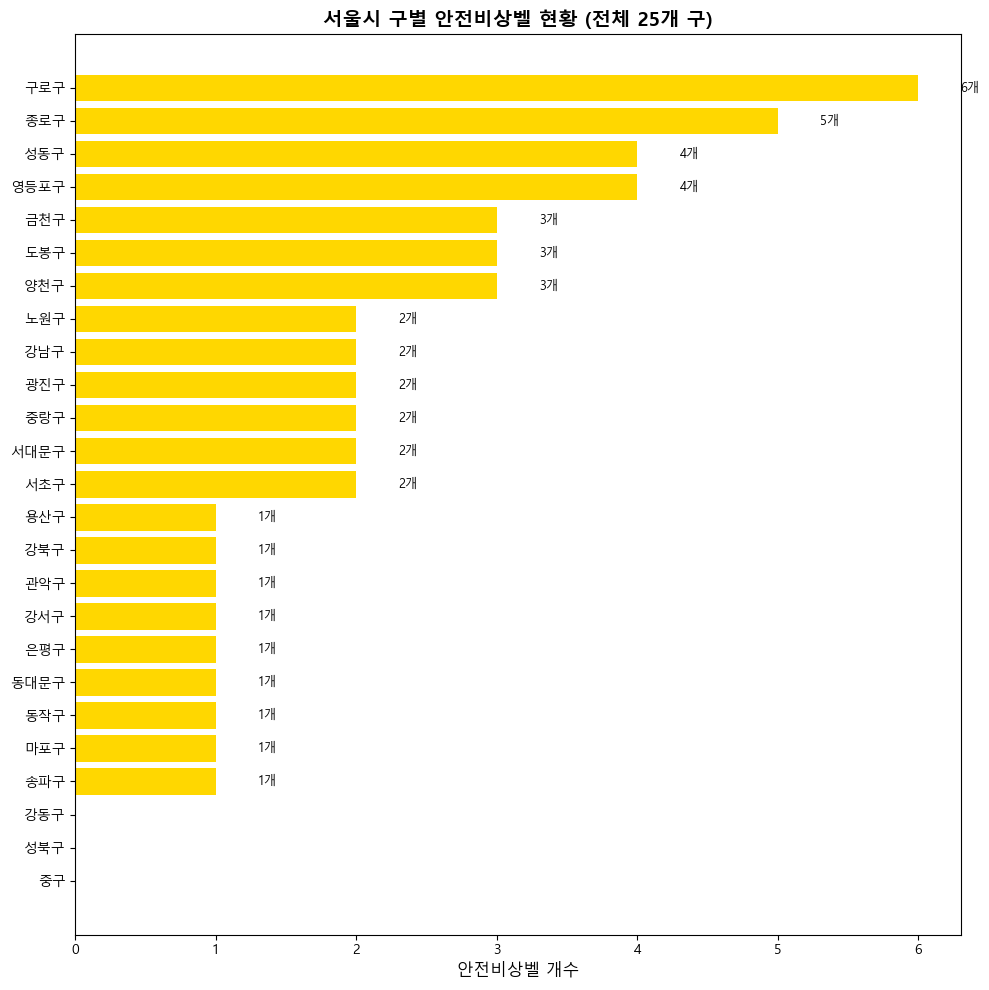


총 안전비상벨: 49개
설치된 구: 22개
미설치 구: 3개


In [26]:
# 서울 25개 구 목록
seoul_districts = [
    '강남구', '강동구', '강북구', '강서구', '관악구', '광진구', '구로구', '금천구',
    '노원구', '도봉구', '동대문구', '동작구', '마포구', '서대문구', '서초구',
    '성동구', '성북구', '송파구', '양천구', '영등포구', '용산구', '은평구',
    '종로구', '중구', '중랑구'
]

# 안전비상벨 구 추출
bell_df['region'] = bell_df['소재지지번주소'].str.extract(r'(?:서울특별시|서울시)?\s*(\S+구)')

# 구별 집계
bell_by_region = bell_df.groupby('region').size().reset_index(name='bell_count')
bell_by_region = bell_by_region.dropna()

print(f"안전비상벨이 있는 구: {len(bell_by_region)}개")
print(f"서울시 전체 구: {len(seoul_districts)}개")

# 누락된 구 확인
extracted = set(bell_by_region['region'].tolist())
missing = set(seoul_districts) - extracted

print(f"\n안전비상벨이 없는 구 ({len(missing)}개):")
print(missing)

# 25개 구 모두 포함하도록 데이터프레임 생성
all_districts_df = pd.DataFrame({'region': seoul_districts})
bell_by_region_full = all_districts_df.merge(bell_by_region, on='region', how='left').fillna(0)
bell_by_region_full['bell_count'] = bell_by_region_full['bell_count'].astype(int)

print("\n=== 전체 25개 구 안전비상벨 현황 ===")
print(bell_by_region_full.sort_values('bell_count', ascending=False))

# 시각화
plt.figure(figsize=(10, 10))

bell_sorted = bell_by_region_full.sort_values('bell_count', ascending=False)
colors = ['gold' if x > 0 else 'lightgray' for x in bell_sorted['bell_count']]
plt.barh(bell_sorted['region'], bell_sorted['bell_count'], color=colors)
plt.xlabel('안전비상벨 개수', fontsize=12)
plt.title('서울시 구별 안전비상벨 현황 (전체 25개 구)', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()

# 값 표시
for idx, row in bell_sorted.iterrows():
    if row['bell_count'] > 0:
        plt.text(row['bell_count'] + 0.3, row['region'], f"{int(row['bell_count'])}개", 
                 va='center', fontsize=9)

plt.tight_layout()
plt.show()

# 통계
print(f"\n총 안전비상벨: {len(bell_df)}개")
print(f"설치된 구: {len(extracted)}개")
print(f"미설치 구: {len(missing)}개")


# 안전온도 계산

In [27]:
# 모든 지표 병합 및 안전온도 계산
from sklearn.preprocessing import MinMaxScaler

# 데이터 병합
merged = crime_visual[['region', 'crime_count']].copy()
merged = merged.merge(cctv_pivot[['안전CCTV합계']].reset_index(), on='region', how='outer')
merged = merged.merge(police_by_region, on='region', how='outer')
merged = merged.merge(fire_by_region, on='region', how='outer')
merged = merged.merge(bell_by_region_full, on='region', how='outer')
merged = merged.fillna(0)

# 정규화 (0-100)
scaler = MinMaxScaler(feature_range=(0, 100))

# 범죄는 역수 (적을수록 안전)
merged['crime_score'] = 100 - scaler.fit_transform(merged[['crime_count']])

# 안전 인프라는 많을수록 안전
merged['cctv_score'] = scaler.fit_transform(merged[['안전CCTV합계']])
merged['police_score'] = scaler.fit_transform(merged[['police_count']])
merged['fire_score'] = scaler.fit_transform(merged[['fire_count']])
merged['bell_score'] = scaler.fit_transform(merged[['bell_count']])

# 안전온도 계산 (가중 평균)
merged['safety_temperature'] = (
    merged['crime_score'] * 0.30 +
    merged['cctv_score'] * 0.30 +
    merged['police_score'] * 0.20 +
    merged['fire_score'] * 0.10 +
    merged['bell_score'] * 0.10
)

# 등급 분류
def safety_grade(temp):
    if temp >= 66:
        return '매우안전'
    elif temp >= 33:
        return '안전'
    else:
        return '주의'

merged['grade'] = merged['safety_temperature'].apply(safety_grade)

print(merged[['region', 'safety_temperature', 'grade']].sort_values('safety_temperature', ascending=False))


   region  safety_temperature grade
2     강북구           62.186053    안전
18    양천구           60.349061    안전
22    종로구           56.738936    안전
9     도봉구           56.322176    안전
14    서초구           55.503121    안전
15    성동구           44.274878    안전
6     구로구           43.421174    안전
16    성북구           42.601278    안전
8     노원구           40.156744    안전
23     중구           39.148629    안전
24    중랑구           38.759150    안전
13   서대문구           38.697268    안전
5     광진구           38.215746    안전
7     금천구           37.135031    안전
10   동대문구           36.287623    안전
3     강서구           35.320097    안전
21    은평구           35.053908    안전
20    용산구           33.304940    안전
11    동작구           32.313758    주의
1     강동구           32.251850    주의
12    마포구           28.793985    주의
0     강남구           28.114529    주의
19   영등포구           26.818671    주의
17    송파구           25.063540    주의
4     관악구           18.145213    주의
